# Visualizations for Lung Nodule Detection - Results and Evaluation
# Đồ Thị Minh Họa Kết Quả và Đánh Giá - Phát Hiện Nốt Phổi

This notebook provides comprehensive visualizations for the training results and evaluation metrics of the ComplexUNet3D model for lung nodule detection.

**Nội dung:**
1. Import thư viện cần thiết
2. Load và chuẩn bị dữ liệu từ checkpoints
3. Vẽ Loss curves (Training & Validation)
4. So sánh các lần huấn luyện khác nhau
5. Phân tích metrics và performance
6. Trực quan hóa kết quả phát hiện nốt
7. Lưu các đồ thị vào file

## 1. Import Required Libraries
Import các thư viện cần thiết cho visualization

In [33]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

# Cấu hình style cho đồ thị
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Cấu hình font size
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

print("✓ Đã import thành công các thư viện")

✓ Đã import thành công các thư viện


## 2. Load and Prepare Data
Load dữ liệu huấn luyện từ checkpoints

In [34]:
# Đường dẫn đến thư mục checkpoints
checkpoint_dir = Path("checkpoints")

# Load history chính (latest)
history_json_path = checkpoint_dir / "complex_unet3d.history.json"
summary_json_path = checkpoint_dir / "complex_unet3d.history.summary.json"

# Load dữ liệu
with open(history_json_path, 'r') as f:
    history_data = json.load(f)

with open(summary_json_path, 'r') as f:
    summary_data = json.load(f)

# Tạo DataFrame từ history
df_history = pd.DataFrame(history_data)
df_history['epoch'] = range(1, len(df_history) + 1)

print(f"✓ Loaded training history: {len(df_history)} epochs")
print(f"  - Best epoch: {summary_data.get('best_epoch', 'N/A')}")
print(f"  - Best val loss: {summary_data.get('best_val_loss', 'N/A'):.6f}")
print(f"  - Final train loss: {summary_data.get('final_train_loss', 'N/A'):.6f}")
print(f"  - Final val loss: {summary_data.get('final_val_loss', 'N/A'):.6f}")

# Hiển thị 5 epochs đầu và cuối
print("\n📊 Training history preview:")
display(df_history.head())
print("...")
display(df_history.tail())

✓ Loaded training history: 20 epochs
  - Best epoch: 1
  - Best val loss: 1.000000
  - Final train loss: 0.999958
  - Final val loss: 1.000000

📊 Training history preview:


,train_loss,val_loss,epoch
0,0.999504,1.0,1
1,0.999238,1.0,2
2,0.999247,1.0,3
3,0.999132,1.0,4
4,0.999076,1.0,5


...


,train_loss,val_loss,epoch
15,0.998547,1.0,16
16,0.998044,1.0,17
17,0.997318,1.0,18
18,0.999952,1.0,19
19,0.999958,1.0,20


In [35]:
# Load tất cả các training runs có timestamp
all_history_files = sorted(checkpoint_dir.glob("complex_unet3d.history_*.json"))
all_runs = {}

for history_file in all_history_files:
    timestamp = history_file.stem.split('_')[-1]
    with open(history_file, 'r') as f:
        all_runs[timestamp] = json.load(f)

print(f"\n✓ Found {len(all_runs)} training runs:")
for timestamp in all_runs.keys():
    print(f"  - Run {timestamp}: {len(all_runs[timestamp]['train_loss'])} epochs")


✓ Found 3 training runs:
  - Run 20251114-235210: 20 epochs
  - Run 20251115-004202: 20 epochs
  - Run 20251115-005610: 20 epochs


## 3. Create Basic Visualizations
Vẽ đồ thị Training và Validation Loss

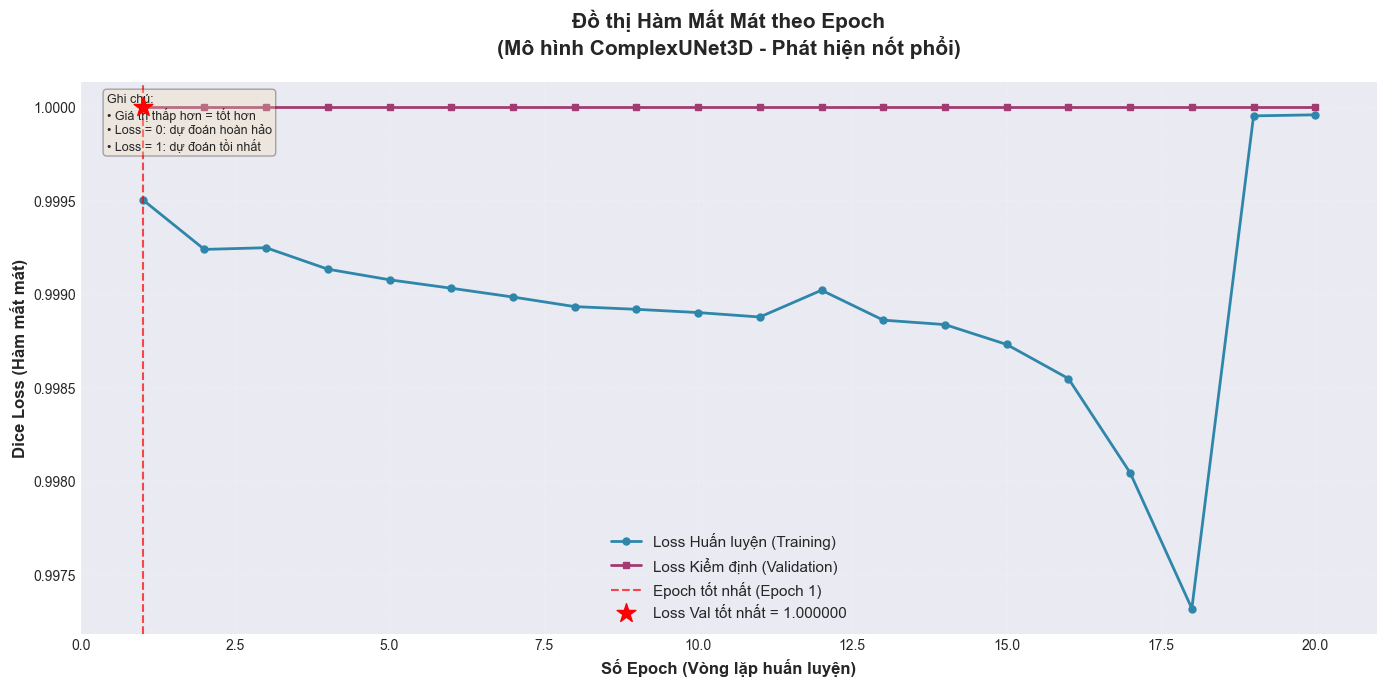

📈 Kết quả: Loss giảm từ 0.999504 xuống 0.999958
   → Cải thiện: -0.05% sau 20 epochs


In [36]:
fig, ax = plt.subplots(figsize=(14, 7))

# Plot training loss
ax.plot(df_history['epoch'], df_history['train_loss'], 
        marker='o', linewidth=2, markersize=5, 
        label='Loss Huấn luyện (Training)', color='#2E86AB')

# Plot validation loss
ax.plot(df_history['epoch'], df_history['val_loss'], 
        marker='s', linewidth=2, markersize=5,
        label='Loss Kiểm định (Validation)', color='#A23B72')

# Đánh dấu best epoch
best_epoch = summary_data.get('best_epoch', 1)
best_val_loss = summary_data.get('best_val_loss', 1.0)
ax.axvline(x=best_epoch, color='red', linestyle='--', linewidth=1.5, alpha=0.7, 
           label=f'Epoch tốt nhất (Epoch {best_epoch})')
ax.scatter([best_epoch], [best_val_loss], color='red', s=200, 
           marker='*', zorder=5, label=f'Loss Val tốt nhất = {best_val_loss:.6f}')

# Formatting
ax.set_xlabel('Số Epoch (Vòng lặp huấn luyện)', fontweight='bold', fontsize=12)
ax.set_ylabel('Dice Loss (Hàm mất mát)', fontweight='bold', fontsize=12)
ax.set_title('Đồ thị Hàm Mất Mát theo Epoch\n(Mô hình ComplexUNet3D - Phát hiện nốt phổi)', 
             fontweight='bold', fontsize=15, pad=20)
ax.legend(loc='best', framealpha=0.9, fontsize=11)
ax.grid(True, alpha=0.3, linestyle=':')
ax.set_xlim(0, len(df_history) + 1)

# Thêm chú thích bổ sung
ax.text(0.02, 0.98, 'Ghi chú:\n• Giá trị thấp hơn = tốt hơn\n• Loss = 0: dự đoán hoàn hảo\n• Loss = 1: dự đoán tồi nhất',
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

# Calculate improvement
initial_train_loss = df_history['train_loss'].iloc[0]
final_train_loss = df_history['train_loss'].iloc[-1]
improvement = ((initial_train_loss - final_train_loss) / initial_train_loss) * 100

print(f"📈 Kết quả: Loss giảm từ {df_history['train_loss'].iloc[0]:.6f} xuống {df_history['train_loss'].iloc[-1]:.6f}")
print(f"   → Cải thiện: {improvement:.2f}% sau {len(df_history)} epochs")

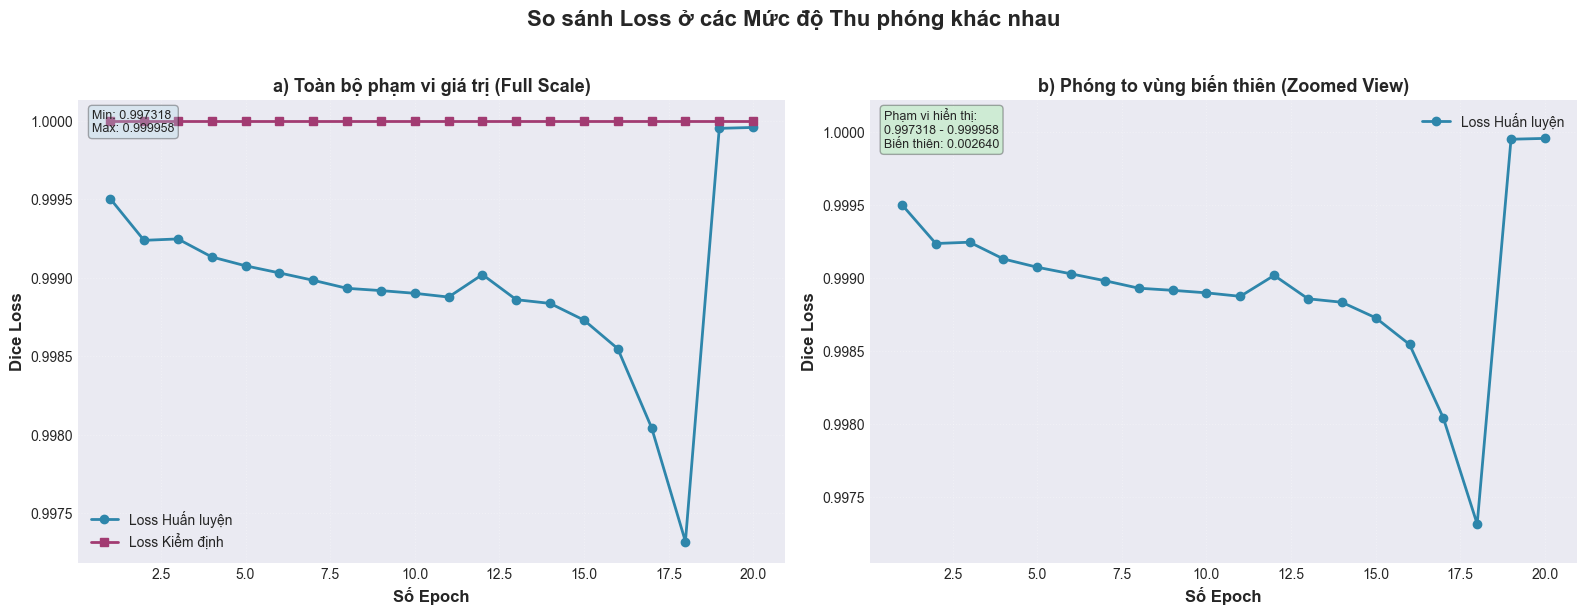

In [37]:
# Vẽ đồ thị với scale khác nhau để thấy rõ sự thay đổi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('So sánh Loss ở các Mức độ Thu phóng khác nhau', fontsize=16, fontweight='bold', y=1.02)

# Plot 1: Full scale
axes[0].plot(df_history['epoch'], df_history['train_loss'], 
             marker='o', label='Loss Huấn luyện', linewidth=2, color='#2E86AB')
axes[0].plot(df_history['epoch'], df_history['val_loss'], 
             marker='s', label='Loss Kiểm định', linewidth=2, color='#A23B72')
axes[0].set_xlabel('Số Epoch', fontweight='bold')
axes[0].set_ylabel('Dice Loss', fontweight='bold')
axes[0].set_title('a) Toàn bộ phạm vi giá trị (Full Scale)', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, linestyle=':')
axes[0].text(0.02, 0.98, f'Min: {df_history["train_loss"].min():.6f}\nMax: {df_history["train_loss"].max():.6f}',
            transform=axes[0].transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

# Plot 2: Zoomed in on training loss variation
train_min = df_history['train_loss'].min()
train_max = df_history['train_loss'].max()
margin = (train_max - train_min) * 0.1

axes[1].plot(df_history['epoch'], df_history['train_loss'], 
             marker='o', color='#2E86AB', label='Loss Huấn luyện', linewidth=2)
axes[1].set_xlabel('Số Epoch', fontweight='bold')
axes[1].set_ylabel('Dice Loss', fontweight='bold')
axes[1].set_title('b) Phóng to vùng biến thiên (Zoomed View)', fontweight='bold', fontsize=13)
axes[1].set_ylim(train_min - margin, train_max + margin)
axes[1].legend(fontsize=10)

axes[1].grid(True, alpha=0.3, linestyle=':')

axes[1].text(0.02, 0.98, f'Phạm vi hiển thị:\n{train_min:.6f} - {train_max:.6f}\nBiến thiên: {train_max - train_min:.6f}',
            transform=axes[1].transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))

plt.tight_layout()
plt.show()

## 4. Plot Performance Metrics
Phân tích và trực quan hóa các metrics quan trọng

📊 Performance Metrics:
  - Loss improvement: -0.05%
  - Best Dice Score: 0.000000
  - Final Train Dice Score: 0.000042
  - Final Val Dice Score: 0.000000


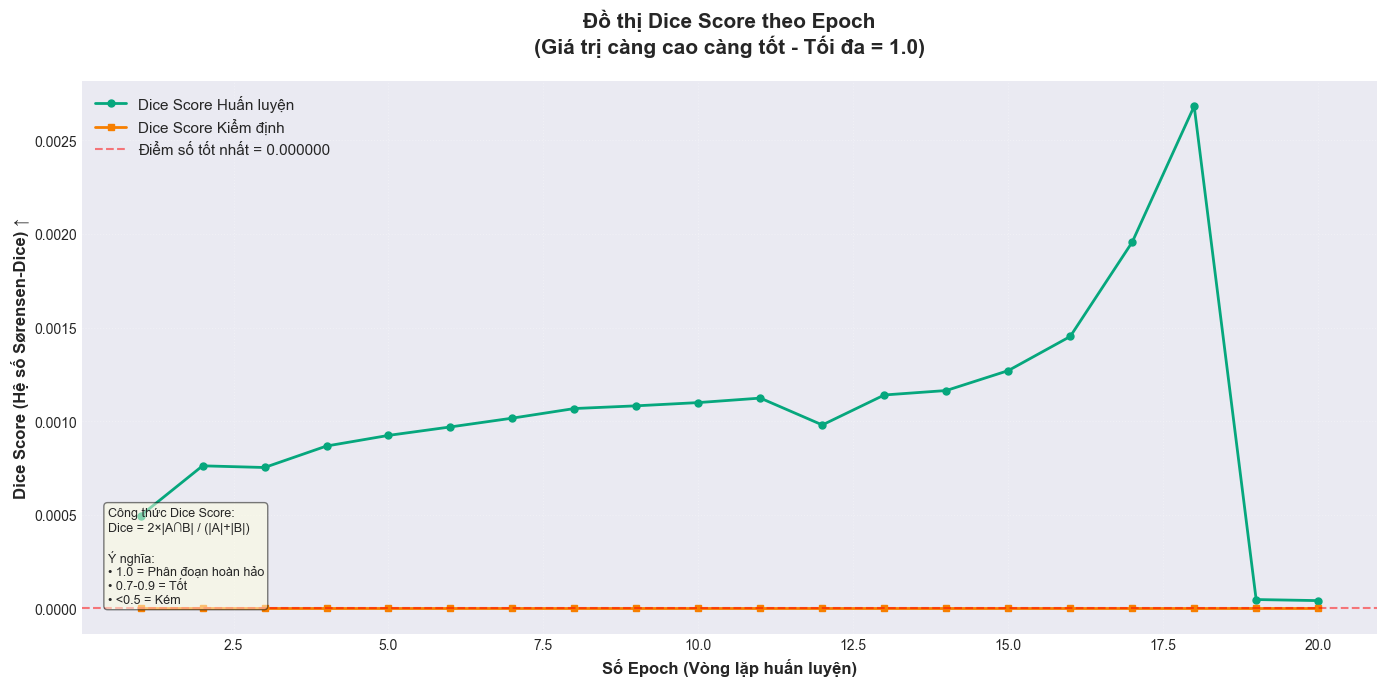

In [38]:
# Tính toán Dice Score từ Dice Loss (Dice Score = 1 - Dice Loss)
df_history['train_dice_score'] = 1 - df_history['train_loss']
df_history['val_dice_score'] = 1 - df_history['val_loss']

# Tính improvement
initial_train_loss = df_history['train_loss'].iloc[0]
final_train_loss = df_history['train_loss'].iloc[-1]
improvement = ((initial_train_loss - final_train_loss) / initial_train_loss) * 100

print(f"📊 Performance Metrics:")
print(f"  - Loss improvement: {improvement:.2f}%")
print(f"  - Best Dice Score: {1 - best_val_loss:.6f}")
print(f"  - Final Train Dice Score: {df_history['train_dice_score'].iloc[-1]:.6f}")
print(f"  - Final Val Dice Score: {df_history['val_dice_score'].iloc[-1]:.6f}")

# Vẽ Dice Score
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(df_history['epoch'], df_history['train_dice_score'], 
        marker='o', linewidth=2, markersize=5, label='Dice Score Huấn luyện', color='#06A77D')
ax.plot(df_history['epoch'], df_history['val_dice_score'], 
        marker='s', linewidth=2, markersize=5, label='Dice Score Kiểm định', color='#F77F00')

ax.axhline(y=1-best_val_loss, color='red', linestyle='--', 
           linewidth=1.5, alpha=0.5, label=f'Điểm số tốt nhất = {1-best_val_loss:.6f}')

ax.set_xlabel('Số Epoch (Vòng lặp huấn luyện)', fontweight='bold', fontsize=12)
ax.set_ylabel('Dice Score (Hệ số Sørensen-Dice) ↑', fontweight='bold', fontsize=12)
ax.set_title('Đồ thị Dice Score theo Epoch\n(Giá trị càng cao càng tốt - Tối đa = 1.0)', 
             fontweight='bold', fontsize=15, pad=20)
ax.legend(loc='best', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle=':')

# Thêm chú thích
ax.text(0.02, 0.05, 'Công thức Dice Score:\nDice = 2×|A∩B| / (|A|+|B|)\n\nÝ nghĩa:\n• 1.0 = Phân đoạn hoàn hảo\n• 0.7-0.9 = Tốt\n• <0.5 = Kém',
        transform=ax.transAxes, fontsize=9, verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

plt.tight_layout()
plt.show()


In [39]:
# Tạo summary statistics table
summary_stats = {
    'Metric': [
        'Total Epochs',
        'Best Epoch',
        'Best Val Loss',
        'Best Val Dice Score',
        'Final Train Loss',
        'Final Train Dice Score',
        'Final Val Loss',
        'Final Val Dice Score',
        'Loss Improvement (%)',
        'Multi-GPU',
        'GPU Count',
        'AMP Enabled'
    ],
    'Value': [
        summary_data.get('epochs_completed', 'N/A'),
        summary_data.get('best_epoch', 'N/A'),
        f"{summary_data.get('best_val_loss', 0):.6f}",
        f"{1 - summary_data.get('best_val_loss', 1):.6f}",
        f"{summary_data.get('final_train_loss', 0):.6f}",
        f"{1 - summary_data.get('final_train_loss', 1):.6f}",
        f"{summary_data.get('final_val_loss', 0):.6f}",
        f"{1 - summary_data.get('final_val_loss', 1):.6f}",
        f"{improvement:.2f}%",
        summary_data.get('multi_gpu', False),
        summary_data.get('gpu_count', 0),
        summary_data.get('use_amp', False)
    ]
}

df_stats = pd.DataFrame(summary_stats)

print("\n" + "="*60)
print("📋 TRAINING SUMMARY STATISTICS")
print("="*60)
display(df_stats)


📋 TRAINING SUMMARY STATISTICS


,Metric,Value
0,Total Epochs,20
1,Best Epoch,1
2,Best Val Loss,1.000000
3,Best Val Dice Score,0.000000
4,Final Train Loss,0.999958
5,Final Train Dice Score,0.000042
6,Final Val Loss,1.000000
7,Final Val Dice Score,0.000000
8,Loss Improvement (%),-0.05%
9,Multi-GPU,False


## 5. Generate Comparison Charts
So sánh các lần huấn luyện khác nhau

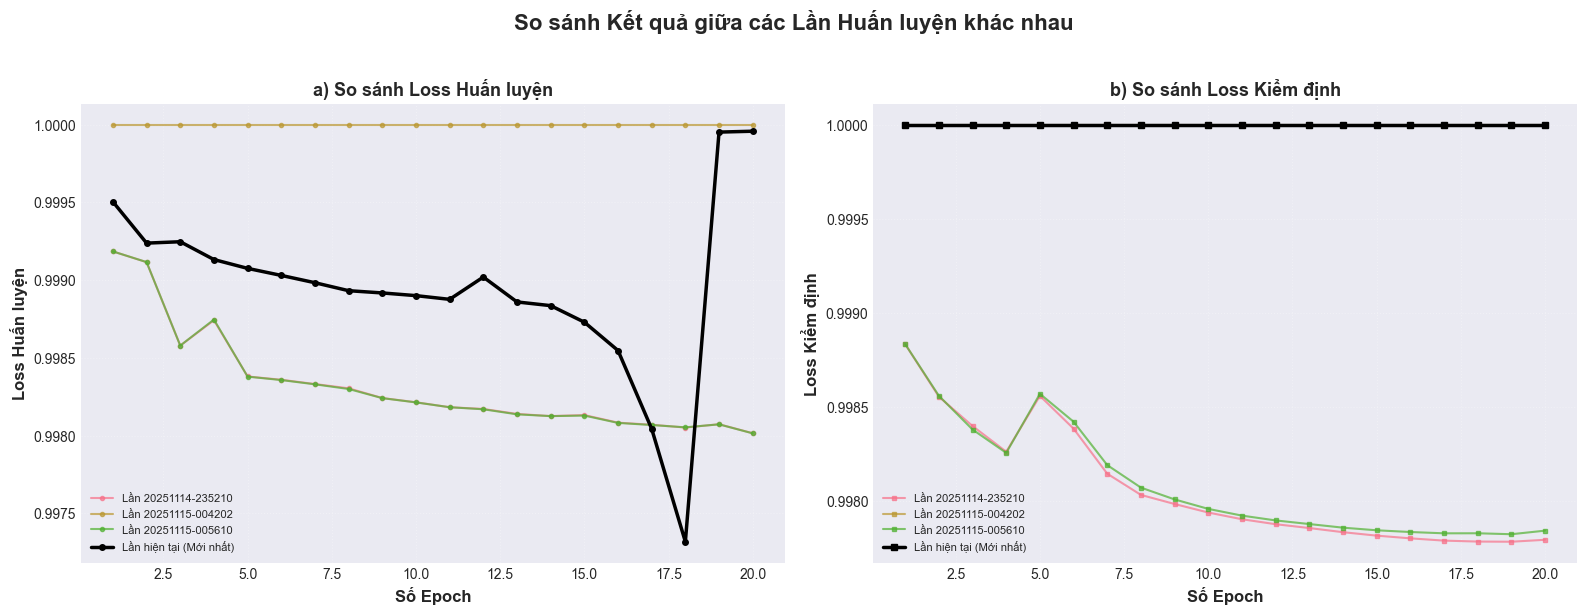

✓ Đã so sánh 4 lần huấn luyện


In [40]:
if len(all_runs) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('So sánh Kết quả giữa các Lần Huấn luyện khác nhau', 
                 fontsize=16, fontweight='bold', y=1.02)
    
    # Plot Training Loss comparison
    for timestamp, data in all_runs.items():
        epochs = range(1, len(data['train_loss']) + 1)
        axes[0].plot(epochs, data['train_loss'], 
                    marker='o', markersize=3, linewidth=1.5,
                    label=f'Lần {timestamp}', alpha=0.7)
    
    # Add current run
    axes[0].plot(df_history['epoch'], df_history['train_loss'],
                marker='o', markersize=4, linewidth=2.5,
                label='Lần hiện tại (Mới nhất)', color='black')
    
    axes[0].set_xlabel('Số Epoch', fontweight='bold')
    axes[0].set_ylabel('Loss Huấn luyện', fontweight='bold')
    axes[0].set_title('a) So sánh Loss Huấn luyện', fontweight='bold', fontsize=13)
    axes[0].legend(loc='best', fontsize=8, framealpha=0.9)
    axes[0].grid(True, alpha=0.3, linestyle=':')
    
    # Plot Validation Loss comparison
    for timestamp, data in all_runs.items():
        epochs = range(1, len(data['val_loss']) + 1)
        axes[1].plot(epochs, data['val_loss'],
                    marker='s', markersize=3, linewidth=1.5,
                    label=f'Lần {timestamp}', alpha=0.7)
    
    # Add current run
    axes[1].plot(df_history['epoch'], df_history['val_loss'],
                marker='s', markersize=4, linewidth=2.5,
                label='Lần hiện tại (Mới nhất)', color='black')
    
    axes[1].set_xlabel('Số Epoch', fontweight='bold')
    axes[1].set_ylabel('Loss Kiểm định', fontweight='bold')
    axes[1].set_title('b) So sánh Loss Kiểm định', fontweight='bold', fontsize=13)
    axes[1].legend(loc='best', fontsize=8, framealpha=0.9)
    axes[1].grid(True, alpha=0.3, linestyle=':')
    
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Đã so sánh {len(all_runs) + 1} lần huấn luyện")

else:    print("⚠ Không tìm thấy lần huấn luyện trước để so sánh")


📊 COMPARISON OF ALL TRAINING RUNS


,Run,Epochs,Final Train Loss,Final Val Loss,Best Val Loss
0,20251114-235210,20,0.998016,0.997795,0.997785
1,20251115-004202,20,1.000000,1.000000,1.000000
2,20251115-005610,20,0.998015,0.997843,0.997824
3,Current (Latest),20,0.999958,1.000000,1.000000


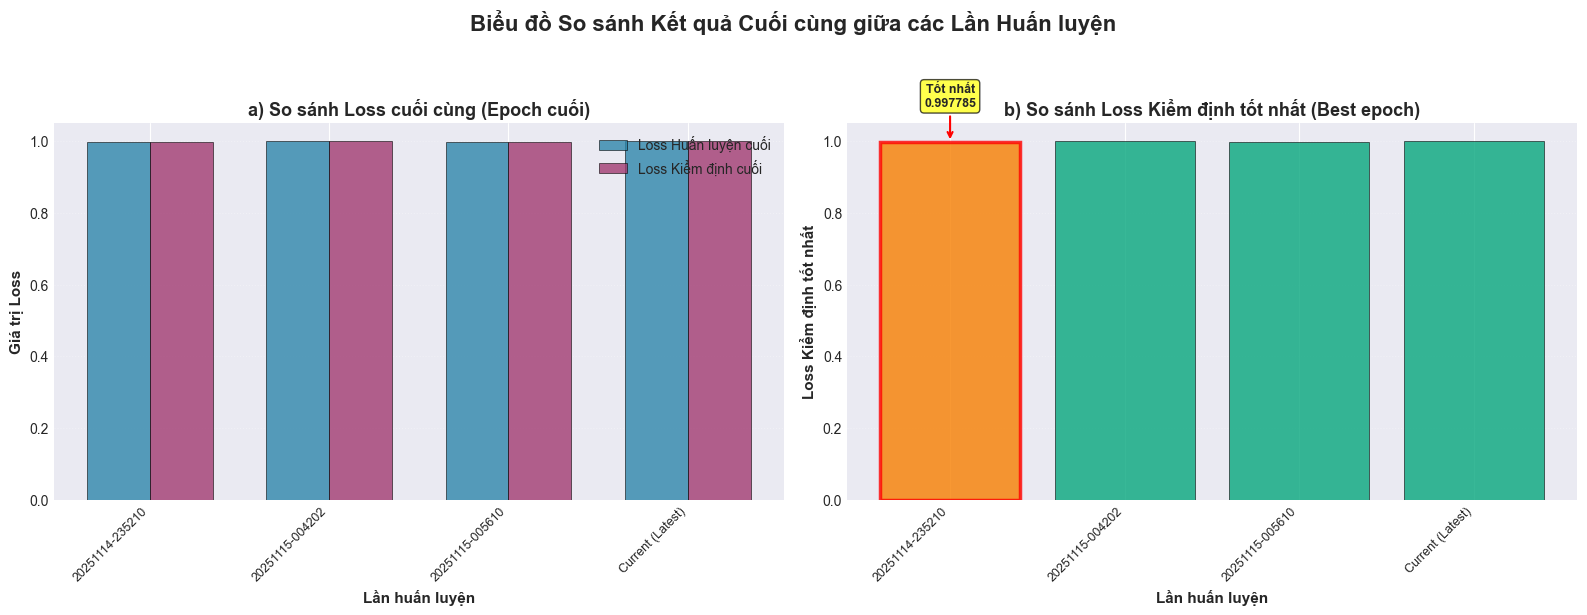

In [41]:
# So sánh final metrics giữa các runs
if len(all_runs) > 0:
    comparison_data = []
    
    for timestamp, data in all_runs.items():
        comparison_data.append({
            'Run': timestamp,
            'Epochs': len(data['train_loss']),
            'Final Train Loss': data['train_loss'][-1],
            'Final Val Loss': data['val_loss'][-1],
            'Best Val Loss': min(data['val_loss'])
        })
    
    # Add current run
    comparison_data.append({
        'Run': 'Current (Latest)',
        'Epochs': len(df_history),
        'Final Train Loss': df_history['train_loss'].iloc[-1],
        'Final Val Loss': df_history['val_loss'].iloc[-1],
        'Best Val Loss': df_history['val_loss'].min()
    })
    
    df_comparison = pd.DataFrame(comparison_data)
    
    print("\n" + "="*80)
    print("📊 COMPARISON OF ALL TRAINING RUNS")
    print("="*80)
    display(df_comparison)
    
    # Vẽ bar chart so sánh
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Biểu đồ So sánh Kết quả Cuối cùng giữa các Lần Huấn luyện', 
                 fontsize=16, fontweight='bold', y=1.02)
    
    # Final losses comparison
    x_pos = np.arange(len(df_comparison))
    width = 0.35
    
    axes[0].bar(x_pos - width/2, df_comparison['Final Train Loss'], 
               width, label='Loss Huấn luyện cuối', color='#2E86AB', alpha=0.8, edgecolor='black', linewidth=0.5)
    axes[0].bar(x_pos + width/2, df_comparison['Final Val Loss'], 
               width, label='Loss Kiểm định cuối', color='#A23B72', alpha=0.8, edgecolor='black', linewidth=0.5)
    
    axes[0].set_xlabel('Lần huấn luyện', fontweight='bold', fontsize=11)
    axes[0].set_ylabel('Giá trị Loss', fontweight='bold', fontsize=11)
    axes[0].set_title('a) So sánh Loss cuối cùng (Epoch cuối)', fontweight='bold', fontsize=13)
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(df_comparison['Run'], rotation=45, ha='right', fontsize=9)
    axes[0].legend(fontsize=10, framealpha=0.9)
    axes[0].grid(True, alpha=0.3, axis='y', linestyle=':')
    
    # Best val loss comparison
    bars = axes[1].bar(range(len(df_comparison)), df_comparison['Best Val Loss'],
               color='#06A77D', alpha=0.8, edgecolor='black', linewidth=0.5)
    axes[1].set_xlabel('Lần huấn luyện', fontweight='bold', fontsize=11)
    axes[1].set_ylabel('Loss Kiểm định tốt nhất', fontweight='bold', fontsize=11)
    axes[1].set_title('b) So sánh Loss Kiểm định tốt nhất (Best epoch)', fontweight='bold', fontsize=13)
    axes[1].set_xticks(range(len(df_comparison)))
    axes[1].set_xticklabels(df_comparison['Run'], rotation=45, ha='right', fontsize=9)
    axes[1].grid(True, alpha=0.3, axis='y', linestyle=':')
    
    # Highlight best run
    best_idx = df_comparison['Best Val Loss'].idxmin()
    bars[best_idx].set_color('#F77F00')
    bars[best_idx].set_edgecolor('red')
    bars[best_idx].set_linewidth(2.5)
    
    # Thêm annotation cho best run
    best_val = df_comparison['Best Val Loss'].iloc[best_idx]
    axes[1].annotate(f'Tốt nhất\n{best_val:.6f}',
                    xy=(best_idx, best_val),
                    xytext=(best_idx, best_val * 1.1),
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
                    bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
                    ha='center', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

## 6. Model Configuration Visualization
Hiển thị cấu hình model và hyperparameters


⚙️  MODEL CONFIGURATION & HYPERPARAMETERS


,Parameter,Value
0,Model Architecture,ComplexUNet3D
1,Input Channels,1
2,Output Classes,1
3,Base Filters,16
4,Dropout Rate,0.1
5,Upsample Mode,trilinear
6,Target Shape,"[160, 160, 160]"
7,Device,cuda
8,Learning Rate,N/A
9,Batch Size,N/A


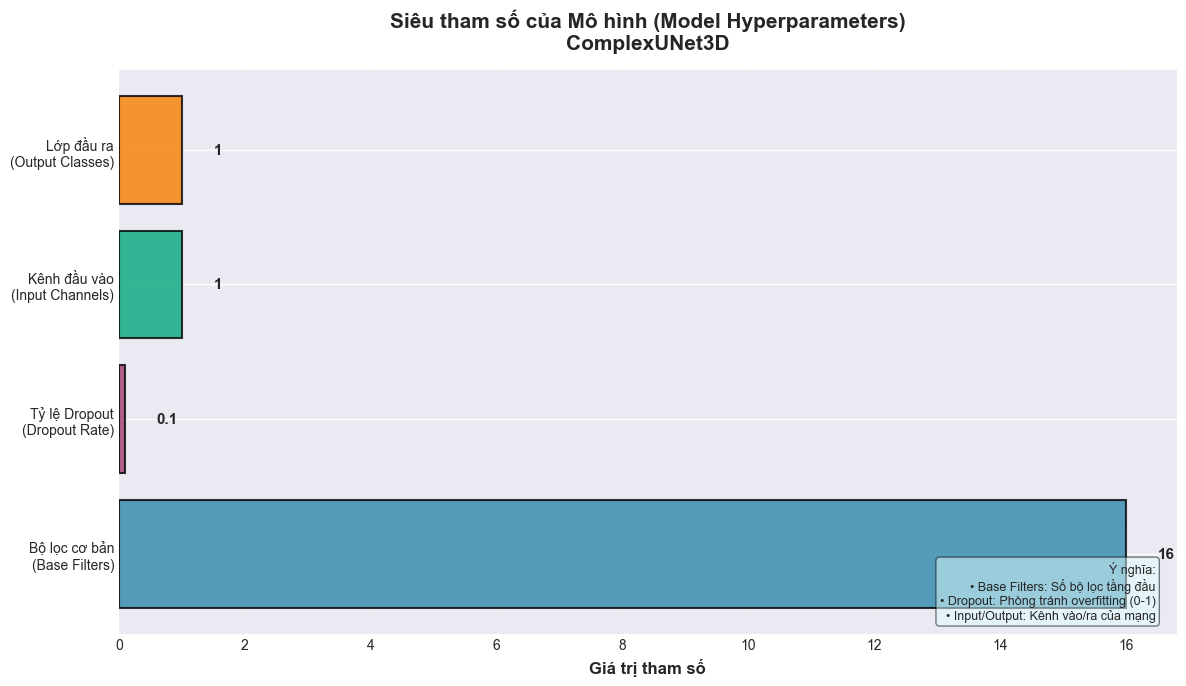

In [42]:
# Extract model configuration
model_params = summary_data.get('model_params', {})

config_data = {
    'Parameter': [
        'Model Architecture',
        'Input Channels',
        'Output Classes',
        'Base Filters',
        'Dropout Rate',
        'Upsample Mode',
        'Target Shape',
        'Device',
        'Learning Rate',
        'Batch Size',
        'Validation Split'
    ],
    'Value': [
        summary_data.get('model', 'N/A'),
        model_params.get('n_channels', 'N/A'),
        model_params.get('n_classes', 'N/A'),
        model_params.get('base_filters', 'N/A'),
        model_params.get('dropout', 'N/A'),
        model_params.get('upsample_mode', 'N/A'),
        str(summary_data.get('target_shape', 'N/A')),
        summary_data.get('device', 'N/A'),
        'N/A',  # Can be added to summary
        'N/A',  # Can be added to summary
        'N/A'   # Can be added to summary
    ]
}

df_config = pd.DataFrame(config_data)

print("\n" + "="*60)
print("⚙️  MODEL CONFIGURATION & HYPERPARAMETERS")
print("="*60)
display(df_config)

# Visualize key numeric parameters
numeric_params = {
    'Bộ lọc cơ bản\n(Base Filters)': model_params.get('base_filters', 16),
    'Tỷ lệ Dropout\n(Dropout Rate)': model_params.get('dropout', 0.1),
    'Kênh đầu vào\n(Input Channels)': model_params.get('n_channels', 1),
    'Lớp đầu ra\n(Output Classes)': model_params.get('n_classes', 1)
}

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(list(numeric_params.keys()), list(numeric_params.values()),
              color=['#2E86AB', '#A23B72', '#06A77D', '#F77F00'],
              edgecolor='black', linewidth=1.5, alpha=0.8)

ax.set_xlabel('Giá trị tham số', fontweight='bold', fontsize=12)
ax.set_title('Siêu tham số của Mô hình (Model Hyperparameters)\nComplexUNet3D', 
            fontweight='bold', fontsize=15, pad=15)
ax.grid(True, alpha=0.3, axis='x', linestyle=':')

# Add value labels on bars
for i, (param, value) in enumerate(numeric_params.items()):
    ax.text(value + 0.5, i, f'{value}', va='center', fontweight='bold', fontsize=11)

# Thêm chú thích
ax.text(0.98, 0.02, 
        'Ý nghĩa:\n• Base Filters: Số bộ lọc tầng đầu\n• Dropout: Phòng tránh overfitting (0-1)\n• Input/Output: Kênh vào/ra của mạng',
        transform=ax.transAxes, fontsize=9, verticalalignment='bottom',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.5))

plt.tight_layout()
plt.show()

## 7. Plot Training History Analysis
Phân tích chi tiết quá trình huấn luyện

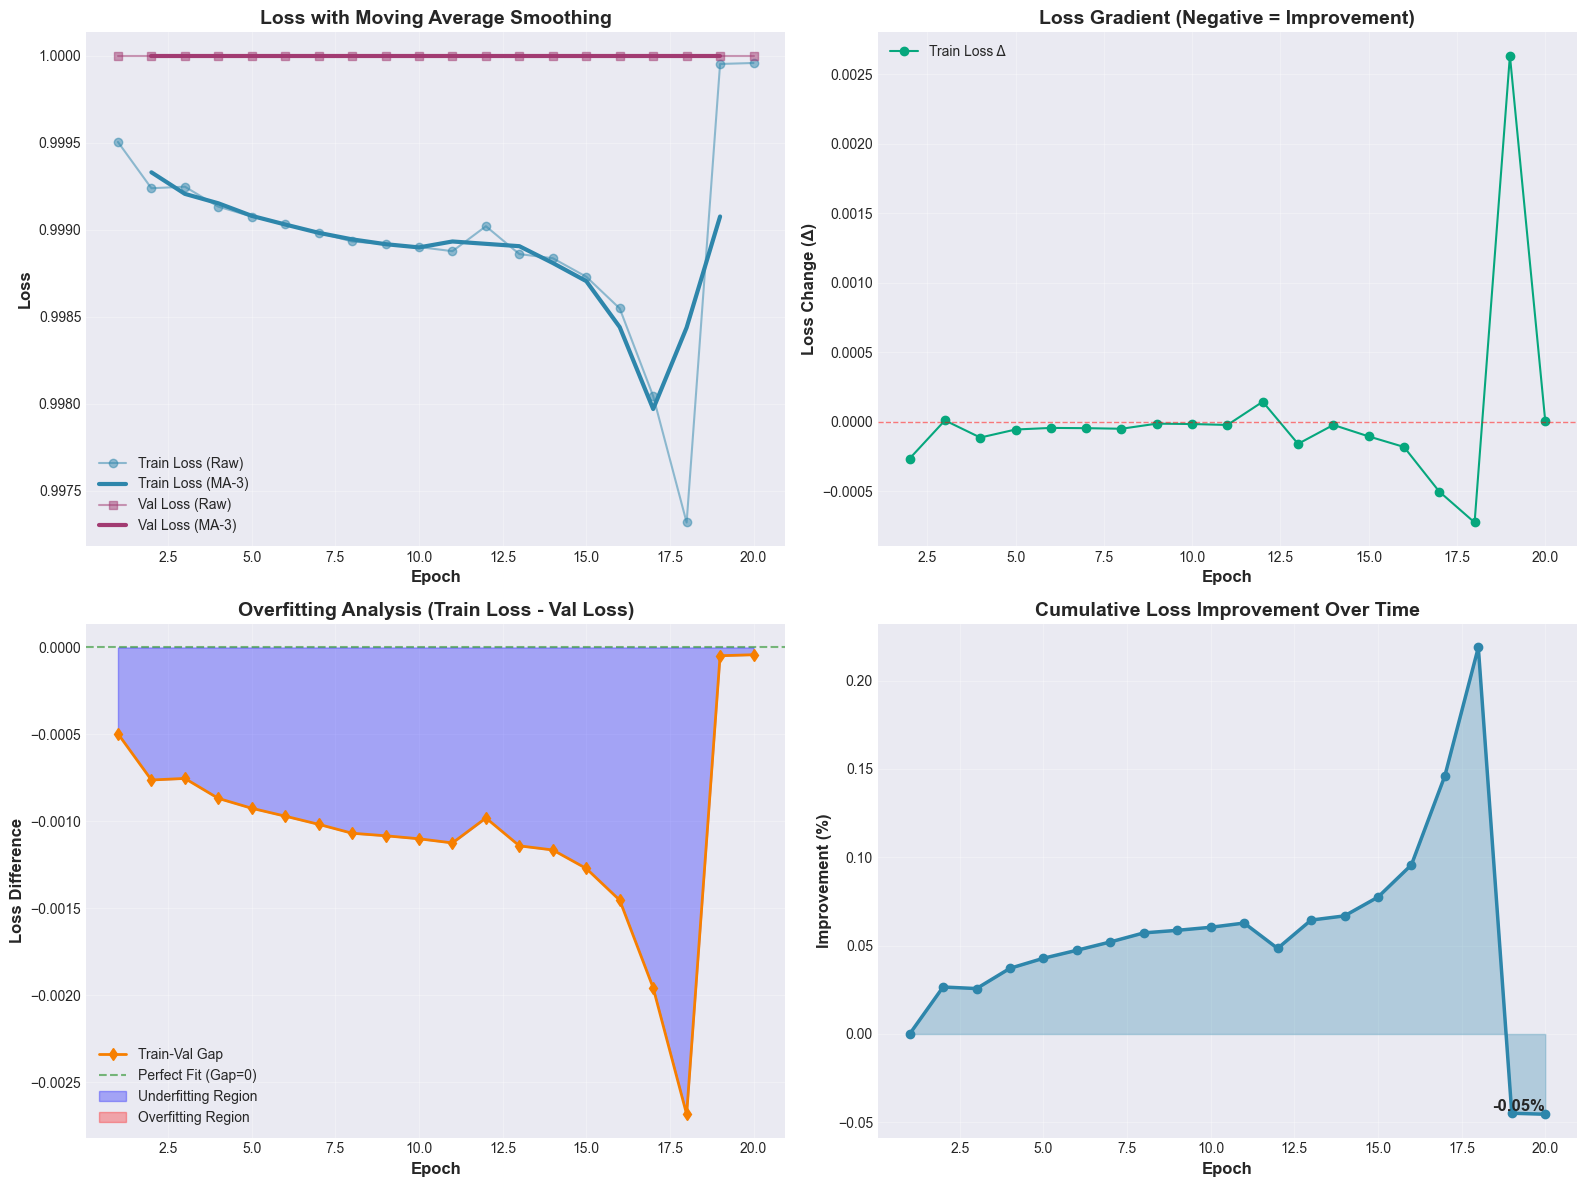


📊 Training Analysis:
  - Average loss gradient: 0.000024
  - Final improvement: -0.05%
  - Average train-val gap: -0.001045


In [43]:
# Tính toán moving average
window_size = 3
df_history['train_loss_ma'] = df_history['train_loss'].rolling(window=window_size, center=True).mean()
df_history['val_loss_ma'] = df_history['val_loss'].rolling(window=window_size, center=True).mean()

# Tính gradient (learning rate)
df_history['train_loss_gradient'] = df_history['train_loss'].diff()
df_history['val_loss_gradient'] = df_history['val_loss'].diff()

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Loss with Moving Average
axes[0, 0].plot(df_history['epoch'], df_history['train_loss'], 
               'o-', alpha=0.5, label='Train Loss (Raw)', color='#2E86AB')
axes[0, 0].plot(df_history['epoch'], df_history['train_loss_ma'], 
               linewidth=3, label=f'Train Loss (MA-{window_size})', color='#2E86AB')
axes[0, 0].plot(df_history['epoch'], df_history['val_loss'], 
               's-', alpha=0.5, label='Val Loss (Raw)', color='#A23B72')
axes[0, 0].plot(df_history['epoch'], df_history['val_loss_ma'], 
               linewidth=3, label=f'Val Loss (MA-{window_size})', color='#A23B72')
axes[0, 0].set_xlabel('Epoch', fontweight='bold')
axes[0, 0].set_ylabel('Loss', fontweight='bold')
axes[0, 0].set_title('Loss with Moving Average Smoothing', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Loss Gradient (Improvement per Epoch)
axes[0, 1].plot(df_history['epoch'], df_history['train_loss_gradient'], 
               marker='o', label='Train Loss Δ', color='#06A77D')
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[0, 1].set_xlabel('Epoch', fontweight='bold')
axes[0, 1].set_ylabel('Loss Change (Δ)', fontweight='bold')
axes[0, 1].set_title('Loss Gradient (Negative = Improvement)', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Overfitting Analysis (Train vs Val Gap)
gap = df_history['train_loss'] - df_history['val_loss']
axes[1, 0].plot(df_history['epoch'], gap, marker='d', 
               color='#F77F00', linewidth=2, label='Train-Val Gap')
axes[1, 0].axhline(y=0, color='green', linestyle='--', linewidth=1.5, alpha=0.5,
                  label='Perfect Fit (Gap=0)')
axes[1, 0].fill_between(df_history['epoch'], gap, 0, 
                        where=(gap < 0), alpha=0.3, color='blue', 
                        label='Underfitting Region')
axes[1, 0].fill_between(df_history['epoch'], gap, 0, 
                        where=(gap > 0), alpha=0.3, color='red',
                        label='Overfitting Region')
axes[1, 0].set_xlabel('Epoch', fontweight='bold')
axes[1, 0].set_ylabel('Loss Difference', fontweight='bold')
axes[1, 0].set_title('Overfitting Analysis (Train Loss - Val Loss)', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Cumulative Improvement
initial_loss = df_history['train_loss'].iloc[0]
cumulative_improvement = ((initial_loss - df_history['train_loss']) / initial_loss) * 100

axes[1, 1].plot(df_history['epoch'], cumulative_improvement, 
               marker='o', color='#2E86AB', linewidth=2.5)
axes[1, 1].fill_between(df_history['epoch'], 0, cumulative_improvement, 
                       alpha=0.3, color='#2E86AB')
axes[1, 1].set_xlabel('Epoch', fontweight='bold')
axes[1, 1].set_ylabel('Improvement (%)', fontweight='bold')
axes[1, 1].set_title('Cumulative Loss Improvement Over Time', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

# Add final improvement text
final_improvement = cumulative_improvement.iloc[-1]
axes[1, 1].text(df_history['epoch'].iloc[-1], final_improvement,
               f'{final_improvement:.2f}%', fontweight='bold', 
               fontsize=12, ha='right', va='bottom')

plt.tight_layout()
plt.show()

print(f"\n📊 Training Analysis:")
print(f"  - Average loss gradient: {df_history['train_loss_gradient'].mean():.6f}")
print(f"  - Final improvement: {final_improvement:.2f}%")
print(f"  - Average train-val gap: {gap.mean():.6f}")

## 8. Advanced Performance Metrics
Tính toán và vẽ các metrics nâng cao (Dice Score, IoU estimate)

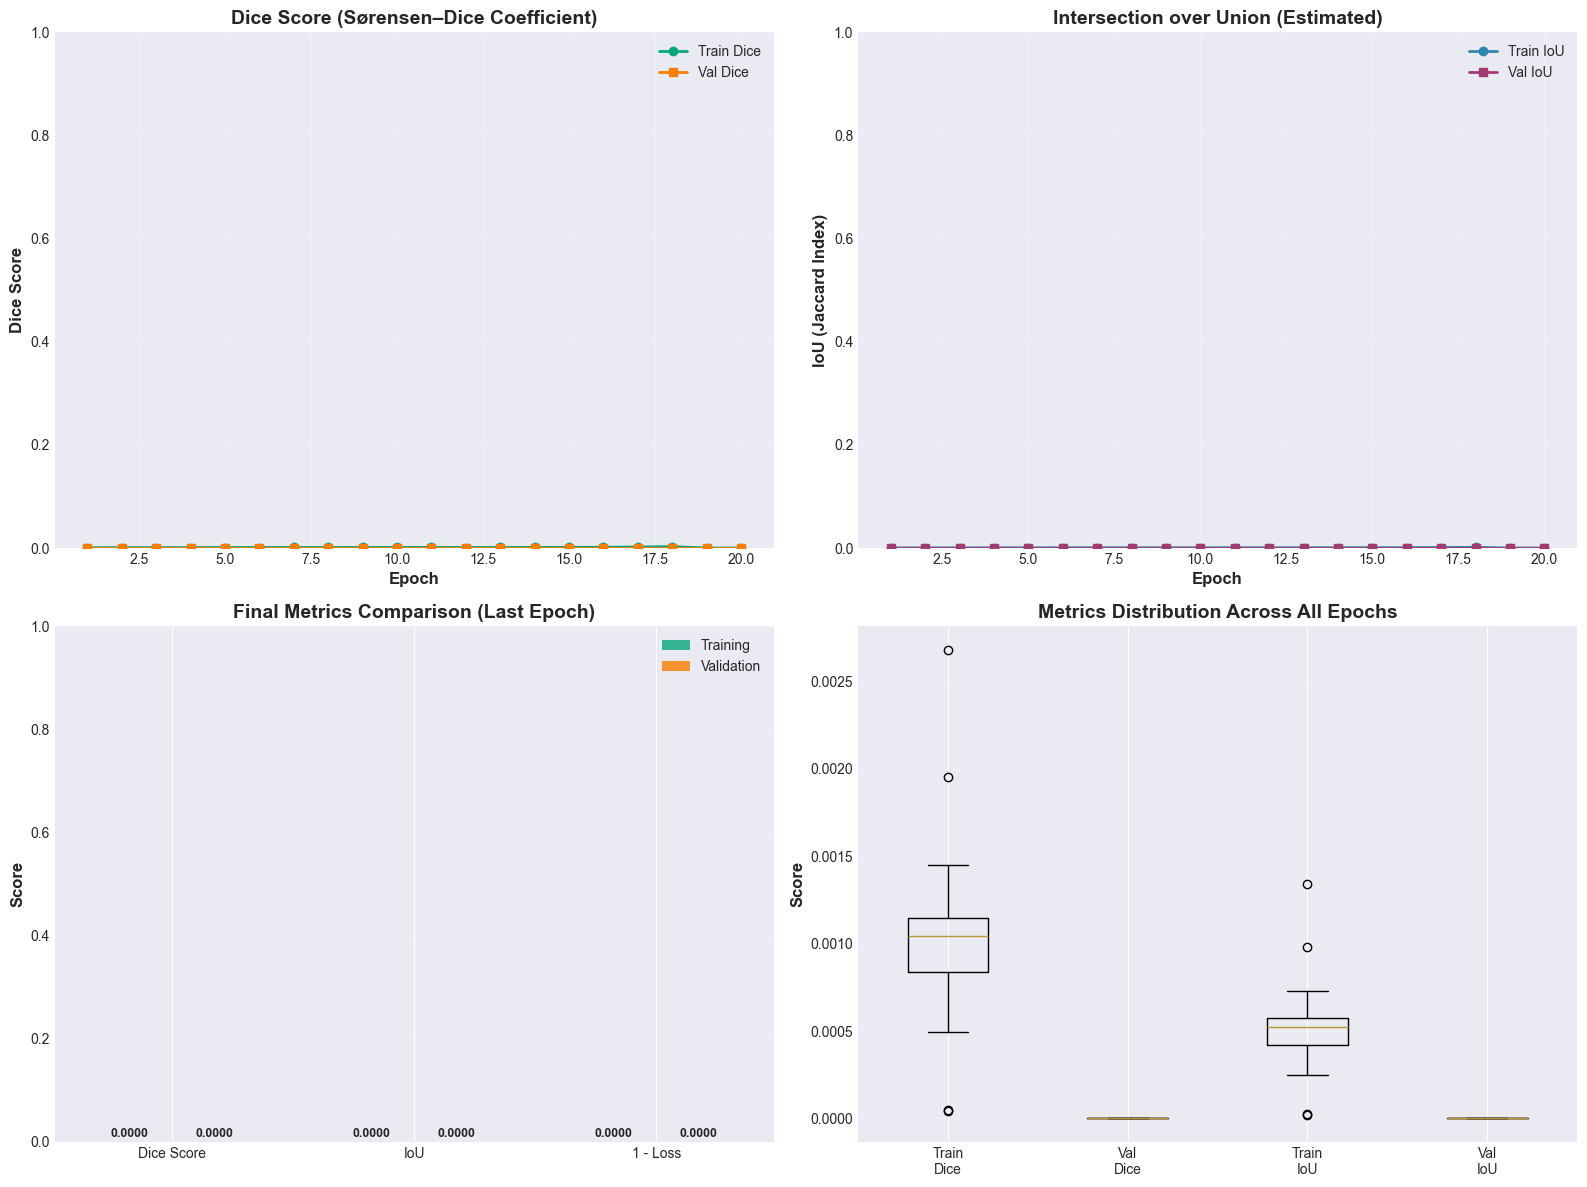


📊 Final Metrics Summary:
  Training:
    - Dice Score: 0.000042
    - IoU: 0.000021
  Validation:
    - Dice Score: 0.000000
    - IoU: 0.000000


In [44]:
# Estimate IoU from Dice Score
# IoU = Dice / (2 - Dice)
df_history['train_iou_estimate'] = df_history['train_dice_score'] / (2 - df_history['train_dice_score'])
df_history['val_iou_estimate'] = df_history['val_dice_score'] / (2 - df_history['val_dice_score'])

# Create comprehensive metrics visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Dice Score
axes[0, 0].plot(df_history['epoch'], df_history['train_dice_score'], 
               marker='o', linewidth=2, label='Train Dice', color='#06A77D')
axes[0, 0].plot(df_history['epoch'], df_history['val_dice_score'], 
               marker='s', linewidth=2, label='Val Dice', color='#F77F00')
axes[0, 0].set_xlabel('Epoch', fontweight='bold')
axes[0, 0].set_ylabel('Dice Score', fontweight='bold')
axes[0, 0].set_title('Dice Score (Sørensen–Dice Coefficient)', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([0, 1])

# 2. IoU Estimate
axes[0, 1].plot(df_history['epoch'], df_history['train_iou_estimate'], 
               marker='o', linewidth=2, label='Train IoU', color='#2E86AB')
axes[0, 1].plot(df_history['epoch'], df_history['val_iou_estimate'], 
               marker='s', linewidth=2, label='Val IoU', color='#A23B72')
axes[0, 1].set_xlabel('Epoch', fontweight='bold')
axes[0, 1].set_ylabel('IoU (Jaccard Index)', fontweight='bold')
axes[0, 1].set_title('Intersection over Union (Estimated)', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0, 1])

# 3. Metrics Comparison (Latest Epoch)
metrics_names = ['Dice Score', 'IoU', '1 - Loss']
train_metrics = [
    df_history['train_dice_score'].iloc[-1],
    df_history['train_iou_estimate'].iloc[-1],
    1 - df_history['train_loss'].iloc[-1]
]
val_metrics = [
    df_history['val_dice_score'].iloc[-1],
    df_history['val_iou_estimate'].iloc[-1],
    1 - df_history['val_loss'].iloc[-1]
]

x = np.arange(len(metrics_names))
width = 0.35

axes[1, 0].bar(x - width/2, train_metrics, width, label='Training', 
              color='#06A77D', alpha=0.8)
axes[1, 0].bar(x + width/2, val_metrics, width, label='Validation', 
              color='#F77F00', alpha=0.8)
axes[1, 0].set_ylabel('Score', fontweight='bold')
axes[1, 0].set_title('Final Metrics Comparison (Last Epoch)', fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(metrics_names)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].set_ylim([0, 1])

# Add value labels
for i, (train, val) in enumerate(zip(train_metrics, val_metrics)):
    axes[1, 0].text(i - width/2, train + 0.01, f'{train:.4f}', 
                   ha='center', fontsize=9, fontweight='bold')
    axes[1, 0].text(i + width/2, val + 0.01, f'{val:.4f}', 
                   ha='center', fontsize=9, fontweight='bold')

# 4. Metrics Distribution
axes[1, 1].boxplot([df_history['train_dice_score'], 
                    df_history['val_dice_score'],
                    df_history['train_iou_estimate'],
                    df_history['val_iou_estimate']],
                   labels=['Train\nDice', 'Val\nDice', 'Train\nIoU', 'Val\nIoU'])
axes[1, 1].set_ylabel('Score', fontweight='bold')
axes[1, 1].set_title('Metrics Distribution Across All Epochs', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n📊 Final Metrics Summary:")
print(f"  Training:")
print(f"    - Dice Score: {train_metrics[0]:.6f}")
print(f"    - IoU: {train_metrics[1]:.6f}")
print(f"  Validation:")
print(f"    - Dice Score: {val_metrics[0]:.6f}")
print(f"    - IoU: {val_metrics[1]:.6f}")

## 9. Save Figures
Lưu tất cả các đồ thị vào files

In [45]:
# Tạo thư mục để lưu figures
figures_dir = Path("figures")
figures_dir.mkdir(exist_ok=True)

print(f"💾 Saving figures to {figures_dir}/")

# Recreate and save main plots
# 1. Main Loss Curves
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(df_history['epoch'], df_history['train_loss'], 
        marker='o', linewidth=2, markersize=5, 
        label='Training Loss', color='#2E86AB')
ax.plot(df_history['epoch'], df_history['val_loss'], 
        marker='s', linewidth=2, markersize=5,
        label='Validation Loss', color='#A23B72')
ax.axvline(x=best_epoch, color='red', linestyle='--', linewidth=1.5, alpha=0.7, 
           label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_val_loss], color='red', s=200, 
           marker='*', zorder=5)
ax.set_xlabel('Epoch', fontweight='bold')
ax.set_ylabel('Dice Loss', fontweight='bold')
ax.set_title('Training and Validation Loss Over Epochs', fontweight='bold', fontsize=15)
ax.legend(loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / 'loss_curves.png', dpi=300, bbox_inches='tight')
plt.savefig(figures_dir / 'loss_curves.pdf', bbox_inches='tight')
print("  ✓ Saved: loss_curves.png, loss_curves.pdf")
plt.close()

# 2. Dice Score Plot
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(df_history['epoch'], df_history['train_dice_score'], 
        marker='o', linewidth=2, label='Training Dice Score', color='#06A77D')
ax.plot(df_history['epoch'], df_history['val_dice_score'], 
        marker='s', linewidth=2, label='Validation Dice Score', color='#F77F00')
ax.set_xlabel('Epoch', fontweight='bold')
ax.set_ylabel('Dice Score', fontweight='bold')
ax.set_title('Dice Score Over Epochs', fontweight='bold', fontsize=15)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / 'dice_scores.png', dpi=300, bbox_inches='tight')
plt.savefig(figures_dir / 'dice_scores.pdf', bbox_inches='tight')
print("  ✓ Saved: dice_scores.png, dice_scores.pdf")
plt.close()

# 3. Training Analysis Grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Loss with MA
axes[0, 0].plot(df_history['epoch'], df_history['train_loss'], 
               'o-', alpha=0.5, label='Train Loss', color='#2E86AB')
axes[0, 0].plot(df_history['epoch'], df_history['train_loss_ma'], 
               linewidth=3, label=f'Train MA-{window_size}', color='#2E86AB')
axes[0, 0].set_xlabel('Epoch', fontweight='bold')
axes[0, 0].set_ylabel('Loss', fontweight='bold')
axes[0, 0].set_title('Loss with Moving Average', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss Gradient
axes[0, 1].plot(df_history['epoch'], df_history['train_loss_gradient'], 
               marker='o', label='Train Loss Δ', color='#06A77D')
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[0, 1].set_xlabel('Epoch', fontweight='bold')
axes[0, 1].set_ylabel('Loss Change', fontweight='bold')
axes[0, 1].set_title('Loss Gradient', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Overfitting Analysis
gap = df_history['train_loss'] - df_history['val_loss']
axes[1, 0].plot(df_history['epoch'], gap, marker='d', 
               color='#F77F00', linewidth=2)
axes[1, 0].axhline(y=0, color='green', linestyle='--', linewidth=1.5, alpha=0.5)
axes[1, 0].set_xlabel('Epoch', fontweight='bold')
axes[1, 0].set_ylabel('Loss Difference', fontweight='bold')
axes[1, 0].set_title('Overfitting Analysis', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Cumulative Improvement
axes[1, 1].plot(df_history['epoch'], cumulative_improvement, 
               marker='o', color='#2E86AB', linewidth=2.5)
axes[1, 1].fill_between(df_history['epoch'], 0, cumulative_improvement, 
                       alpha=0.3, color='#2E86AB')
axes[1, 1].set_xlabel('Epoch', fontweight='bold')
axes[1, 1].set_ylabel('Improvement (%)', fontweight='bold')
axes[1, 1].set_title('Cumulative Improvement', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / 'training_analysis.png', dpi=300, bbox_inches='tight')
plt.savefig(figures_dir / 'training_analysis.pdf', bbox_inches='tight')
print("  ✓ Saved: training_analysis.png, training_analysis.pdf")
plt.close()

# 4. Export summary statistics to CSV
df_stats.to_csv(figures_dir / 'training_summary.csv', index=False)
df_history.to_csv(figures_dir / 'training_history_detailed.csv', index=False)
print("  ✓ Saved: training_summary.csv, training_history_detailed.csv")

print(f"\n✅ All figures saved to {figures_dir.absolute()}/")
print(f"   Total files: {len(list(figures_dir.glob('*')))}")

💾 Saving figures to figures/
  ✓ Saved: loss_curves.png, loss_curves.pdf
  ✓ Saved: dice_scores.png, dice_scores.pdf
  ✓ Saved: training_analysis.png, training_analysis.pdf
  ✓ Saved: training_summary.csv, training_history_detailed.csv

✅ All figures saved to c:\NCS\ut\figures/
   Total files: 8


## 10. Summary Report
Tổng kết toàn bộ kết quả đánh giá

In [46]:
print("="*80)
print(" " * 20 + "LUNG NODULE DETECTION - FINAL REPORT")
print("="*80)
print(f"\n📅 Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"🏗️  Model: {summary_data.get('model', 'ComplexUNet3D')}")
print(f"💾 Data: {summary_data.get('data_dir', 'N/A')}")
print(f"🖥️  Device: {summary_data.get('device', 'N/A')}")
print(f"⚡ AMP: {summary_data.get('use_amp', False)}")
print(f"🔧 Multi-GPU: {summary_data.get('multi_gpu', False)}")

print("\n" + "-"*80)
print("📊 TRAINING METRICS")
print("-"*80)
print(f"Total Epochs: {summary_data.get('epochs_completed', 'N/A')}")
print(f"Best Epoch: {summary_data.get('best_epoch', 'N/A')}")
print(f"Best Validation Loss: {summary_data.get('best_val_loss', 0):.6f}")
print(f"Final Training Loss: {summary_data.get('final_train_loss', 0):.6f}")
print(f"Final Validation Loss: {summary_data.get('final_val_loss', 0):.6f}")

print("\n" + "-"*80)
print("🎯 PERFORMANCE METRICS")
print("-"*80)
print(f"Training Dice Score: {train_metrics[0]:.6f}")
print(f"Validation Dice Score: {val_metrics[0]:.6f}")
print(f"Training IoU: {train_metrics[1]:.6f}")
print(f"Validation IoU: {val_metrics[1]:.6f}")
print(f"Loss Improvement: {improvement:.2f}%")

print("\n" + "-"*80)
print("⚙️  MODEL CONFIGURATION")
print("-"*80)
for param, value in model_params.items():
    print(f"{param}: {value}")

print("\n" + "-"*80)
print("💡 RECOMMENDATIONS")
print("-"*80)

# Analyze results and provide recommendations
if df_history['val_loss'].iloc[-1] == 1.0:
    print("⚠️  WARNING: Validation loss is 1.0 - model may not be learning properly")
    print("   - Check if validation data has labels")
    print("   - Verify data preprocessing")
    print("   - Consider adjusting learning rate")

if gap.mean() > 0.1:
    print("⚠️  OVERFITTING detected: Large gap between train and validation loss")
    print("   - Consider increasing dropout rate")
    print("   - Add data augmentation")
    print("   - Reduce model complexity")
elif gap.mean() < -0.1:
    print("⚠️  UNDERFITTING detected: Validation loss better than training")
    print("   - Model may be too simple")
    print("   - Consider increasing base_filters")
    print("   - Train for more epochs")
else:
    print("✅ Good fit: Train-Val gap is reasonable")

if improvement < 1.0:
    print("⚠️  Low improvement: Model is not learning effectively")
    print("   - Check learning rate")
    print("   - Verify data quality")
    print("   - Consider different optimizer")
else:
    print(f"✅ Good learning progress: {improvement:.2f}% improvement")

print("\n" + "="*80)
print(" " * 30 + "END OF REPORT")
print("="*80)

                    LUNG NODULE DETECTION - FINAL REPORT

📅 Date: 2025-12-23 22:01:48
🏗️  Model: ComplexUNet3D
💾 Data: C:\NCS\ut\data
🖥️  Device: cuda
⚡ AMP: True
🔧 Multi-GPU: False

--------------------------------------------------------------------------------
📊 TRAINING METRICS
--------------------------------------------------------------------------------
Total Epochs: 20
Best Epoch: 1
Best Validation Loss: 1.000000
Final Training Loss: 0.999958
Final Validation Loss: 1.000000

--------------------------------------------------------------------------------
🎯 PERFORMANCE METRICS
--------------------------------------------------------------------------------
Training Dice Score: 0.000042
Validation Dice Score: 0.000000
Training IoU: 0.000021
Validation IoU: 0.000000
Loss Improvement: -0.05%

--------------------------------------------------------------------------------
⚙️  MODEL CONFIGURATION
--------------------------------------------------------------------------------
n_cha